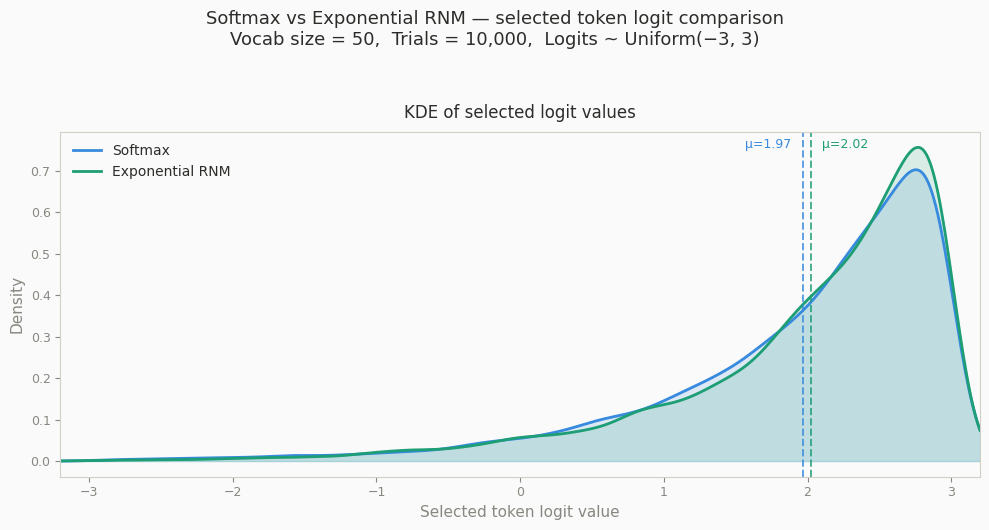

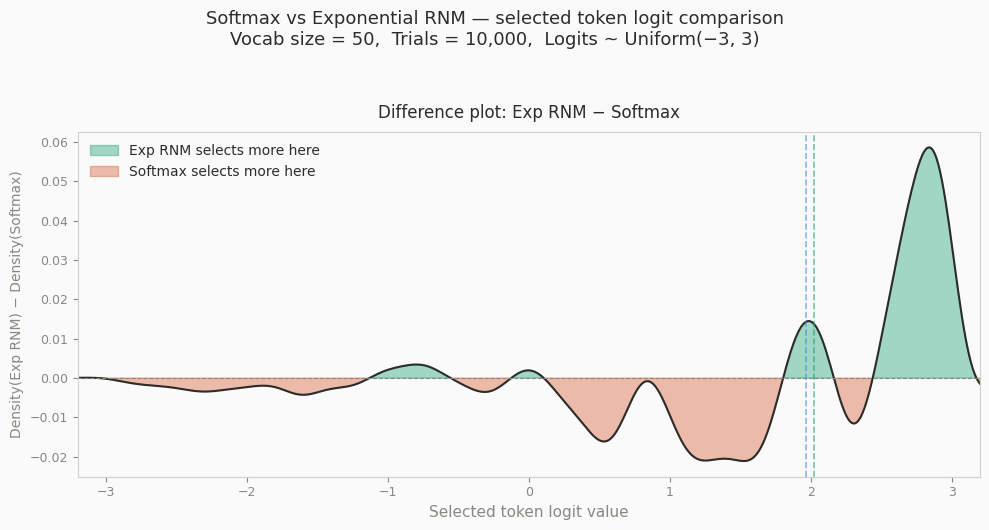


Softmax  mean logit : 1.9679
Exp RNM  mean logit : 2.0209
Improvement         : 0.0531


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

TRIALS = 10000
VOCAB_SIZE = 50

def softmax_select(logits):
    logits = logits - np.max(logits)
    probs = np.exp(logits) / np.sum(np.exp(logits))
    return np.random.choice(len(logits), p=probs)

def exp_rnm_select(logits):
    noise = np.random.exponential(scale=1.0, size=len(logits))
    return np.argmax(logits + noise)

softmax_scores = []
exp_scores = []

for _ in range(TRIALS):
    logits = np.random.uniform(-3, 3, size=VOCAB_SIZE)
    softmax_scores.append(logits[softmax_select(logits)])
    exp_scores.append(logits[exp_rnm_select(logits)])

softmax_scores = np.array(softmax_scores)
exp_scores     = np.array(exp_scores)

softmax_mean = np.mean(softmax_scores)
exp_mean     = np.mean(exp_scores)

BLUE        = "#378ADD"
GREEN       = "#1D9E75"
LIGHT_BLUE  = "#B5D4F4"
LIGHT_GREEN = "#9FE1CB"
CORAL       = "#D85A30"
GRAY        = "#888780"
BG          = "#FAFAFA"
DARK        = "#2C2C2A"

x = np.linspace(-3.2, 3.2, 500)
kde_sm  = gaussian_kde(softmax_scores, bw_method=0.15)
kde_exp = gaussian_kde(exp_scores,     bw_method=0.15)
diff    = kde_exp(x) - kde_sm(x)

title_info = (f"Softmax vs Exponential RNM — selected token logit comparison\n"
              f"Vocab size = {VOCAB_SIZE},  Trials = {TRIALS:,},  Logits ~ Uniform(−3, 3)")

# ==========================================
# PLOT 1: KDE Comparison
# ==========================================
fig1, ax_kde = plt.subplots(figsize=(10, 5), facecolor=BG)
ax_kde.set_facecolor(BG)

for spine in ax_kde.spines.values():
    spine.set_edgecolor("#D3D1C7")
    spine.set_linewidth(0.8)

ax_kde.plot(x, kde_sm(x),  color=BLUE,  linewidth=2,   label="Softmax")
ax_kde.plot(x, kde_exp(x), color=GREEN, linewidth=2,   label="Exponential RNM")
ax_kde.fill_between(x, kde_sm(x),  alpha=0.15, color=BLUE)
ax_kde.fill_between(x, kde_exp(x), alpha=0.15, color=GREEN)
ax_kde.axvline(softmax_mean, color=BLUE,  linewidth=1.4, linestyle="--", alpha=0.8)
ax_kde.axvline(exp_mean,     color=GREEN, linewidth=1.4, linestyle="--", alpha=0.8)

# Calculate text height dynamically based on limits
y_max_kde = ax_kde.get_ylim()[1]
ax_kde.text(softmax_mean - 0.08, y_max_kde * 0.95,
            f"μ={softmax_mean:.2f}", color=BLUE,  fontsize=9, ha="right")
ax_kde.text(exp_mean + 0.08, y_max_kde * 0.95,
            f"μ={exp_mean:.2f}",     color=GREEN, fontsize=9, ha="left")

# Added x-axis label here as requested
ax_kde.set_xlabel("Selected token logit value", fontsize=11, color=GRAY)
ax_kde.set_ylabel("Density", fontsize=11, color=GRAY)
ax_kde.set_title("KDE of selected logit values", fontsize=12,
                 fontweight="normal", color=DARK, pad=10)
ax_kde.legend(fontsize=10, framealpha=0, labelcolor=DARK)
ax_kde.tick_params(colors=GRAY, labelsize=9)
ax_kde.set_xlim(-3.2, 3.2)

fig1.suptitle(title_info, fontsize=13, color=DARK, fontweight="normal", y=1.05)
fig1.tight_layout()
plt.savefig("softmax_vs_exprnm_kde.png", dpi=150, bbox_inches="tight", facecolor=BG)


# ==========================================
# PLOT 2: Difference Plot
# ==========================================
fig2, ax_diff = plt.subplots(figsize=(10, 5), facecolor=BG)
ax_diff.set_facecolor(BG)

for spine in ax_diff.spines.values():
    spine.set_edgecolor("#D3D1C7")
    spine.set_linewidth(0.8)

ax_diff.fill_between(x, diff, where=(diff >= 0),
                     color=GREEN, alpha=0.4, label="Exp RNM selects more here")
ax_diff.fill_between(x, diff, where=(diff < 0),
                     color=CORAL, alpha=0.4, label="Softmax selects more here")
ax_diff.plot(x, diff, color=DARK, linewidth=1.5)
ax_diff.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
ax_diff.axvline(softmax_mean, color=BLUE,  linewidth=1.2, linestyle="--", alpha=0.6)
ax_diff.axvline(exp_mean,     color=GREEN, linewidth=1.2, linestyle="--", alpha=0.6)

ax_diff.set_xlabel("Selected token logit value", fontsize=11, color=GRAY)
ax_diff.set_ylabel("Density(Exp RNM) − Density(Softmax)", fontsize=10, color=GRAY)
ax_diff.set_title("Difference plot: Exp RNM − Softmax", fontsize=12,
                  fontweight="normal", color=DARK, pad=10)
ax_diff.legend(fontsize=10, framealpha=0, labelcolor=DARK)
ax_diff.tick_params(colors=GRAY, labelsize=9)
ax_diff.set_xlim(-3.2, 3.2)

fig2.suptitle(title_info, fontsize=13, color=DARK, fontweight="normal", y=1.05)
fig2.tight_layout()
plt.savefig("softmax_vs_exprnm_diff.png", dpi=150, bbox_inches="tight", facecolor=BG)


# Display both
plt.show()

print(f"\nSoftmax  mean logit : {softmax_mean:.4f}")
print(f"Exp RNM  mean logit : {exp_mean:.4f}")
print(f"Improvement         : {exp_mean - softmax_mean:.4f}")